# House Price Prediction using Linear Regression

## Project Objective

Build a machine learning model to predict house prices using the Ames Housing Dataset.

This project covers:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Categorical encoding
- Log transformation
- Outlier analysis
- Feature selection
- Feature scaling
- Linear Regression
- Model evaluation
- Actual vs Predicted price analysis

## Dataset

Dataset: Ames Housing Dataset

The dataset contains information about residential properties and their sale prices.

Target Variable:
- SalePrice

The original training dataset contains 1460 rows and 81 columns.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Pandas          → dataset handle
NumPy           → numerical calculations

Matplotlib      → graphs
Seaborn         → statistical visualization

train_test_split → train/test data divide
LinearRegression → ML model
StandardScaler   → feature scaling

MAE/MSE/RMSE/R² → model evaluation

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.shape

(1460, 81)

In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond"
]

In [ ]:
df[none_cols] = df[none_cols].fillna("None")

In [ ]:
df[none_cols].isnull().sum()

,0
PoolQC,0
MiscFeature,0
Alley,0
Fence,0
MasVnrType,0
FireplaceQu,0
GarageType,0
GarageFinish,0
GarageQual,0
GarageCond,0


In [ ]:
df["LotFrontage"] = df["LotFrontage"].fillna(
    df["LotFrontage"].median()
)

In [ ]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(
    df["GarageYrBlt"].median()
)

In [ ]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [ ]:
df["Electrical"] = df["Electrical"].fillna(
    df["Electrical"].mode()[0]
)

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of categorical columns: 43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [ ]:
df[categorical_cols].nunique().sort_values()

,0
Street,2
Utilities,2
CentralAir,2
LandSlope,3
Alley,3
PavedDrive,3
MasVnrType,4
LandContour,4
ExterQual,4
KitchenQual,4


In [24]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [27]:
X = pd.get_dummies(X, drop_first = True)

In [28]:
X.shape

(1460, 260)

In [29]:
X.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [30]:
X.dtypes.value_counts()

,count
bool,223
int64,34
float64,3


In [31]:
X.select_dtypes(include=["object"]).columns

Index([], dtype='object')

In [32]:
X.isnull().sum().sum()

np.int64(0)

In [33]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 260)
y shape: (1460,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 260)
X_test: (292, 260)
y_train: (1168,)
y_test: (292,)


In [36]:
model = LinearRegression()

In [37]:
model.fit(X_train, y_train)

LinearRegression()

In [38]:
print("Model trained successfully!")

Model trained successfully!


In [39]:
y_pred = model.predict(X_test)

In [40]:
print(y_pred[:10])

[160201.42730634 343035.07329848  90079.26155317 176365.62603813
 321471.78617872  67933.20461609 239325.9872012  146674.85622378
  62813.64252014 151734.82405674]


In [41]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,154500,160201.427306
1,325000,343035.073298
2,115000,90079.261553
3,159000,176365.626038
4,315500,321471.786179
5,75500,67933.204616
6,311500,239325.987201
7,146000,146674.856224
8,84500,62813.642520
9,135500,151734.824057


In [42]:
comparison["Difference"] = (
    comparison["Actual"] - comparison["Predicted"]
)

comparison.head(10)

,Actual,Predicted,Difference
0,154500,160201.427306,-5701.427306
1,325000,343035.073298,-18035.073298
2,115000,90079.261553,24920.738447
3,159000,176365.626038,-17365.626038
4,315500,321471.786179,-5971.786179
5,75500,67933.204616,7566.795384
6,311500,239325.987201,72174.012799
7,146000,146674.856224,-674.856224
8,84500,62813.642520,21686.357480
9,135500,151734.824057,-16234.824057


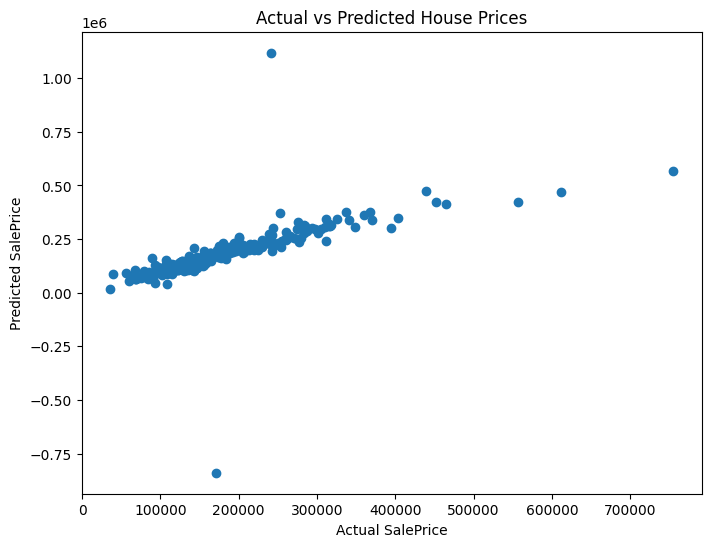

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [44]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 23922.62678223627


In [45]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 6890776624.724271


In [46]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 83010.70186864023


In [47]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.10163186824211123


In [48]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 23922.62678223627
MSE : 6890776624.724271
RMSE: 83010.70186864023
R²  : 0.10163186824211123


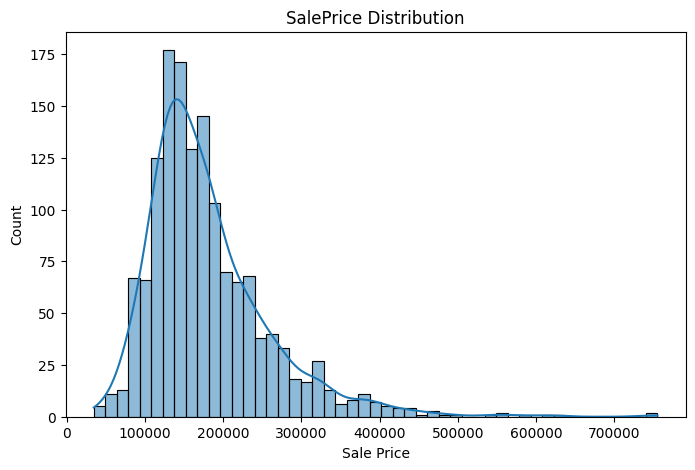

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("SalePrice Distribution")
plt.xlabel("Sale Price")
plt.show()

In [50]:
y = df["SalePrice"]

In [51]:
y_log = np.log1p(y)

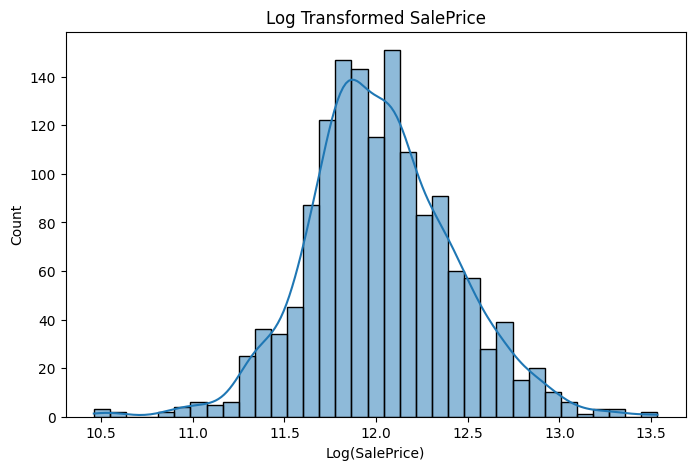

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(y_log, kde=True)

plt.title("Log Transformed SalePrice")
plt.xlabel("Log(SalePrice)")
plt.show()

In [53]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

In [54]:
model_log = LinearRegression()

model_log.fit(X_train, y_train_log)

LinearRegression()

In [55]:
y_pred_log = model_log.predict(X_test)

In [56]:
y_pred = np.expm1(y_pred_log)

In [57]:
y_test_actual = np.expm1(y_test_log)

In [58]:
print("MAE :", mean_absolute_error(y_test_actual, y_pred))
print("MSE :", mean_squared_error(y_test_actual, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred)))
print("R²  :", r2_score(y_test_actual, y_pred))

MAE : 15522.171852429028
MSE : 647968852.3620466
RMSE: 25455.232317974365
R²  : 0.9155226472956395


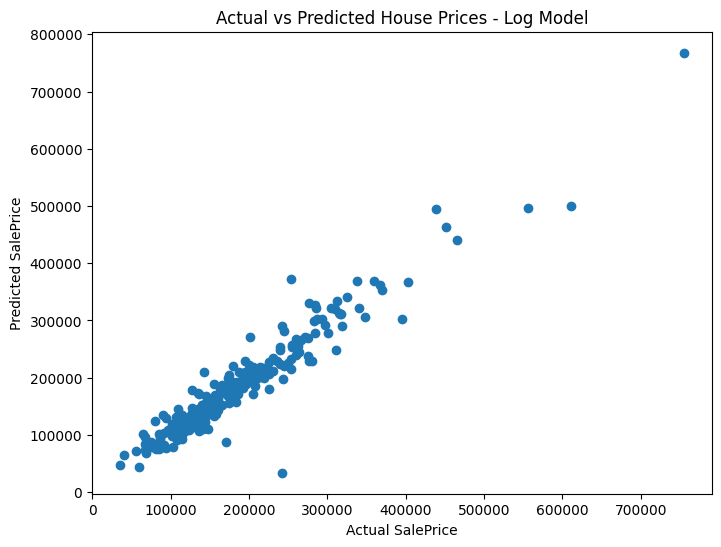

In [59]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_actual, y_pred)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices - Log Model")

plt.show()

In [60]:
comparison_log = pd.DataFrame({
    "Actual": y_test_actual,
    "Predicted": y_pred
})

comparison_log["Error"] = (
    comparison_log["Actual"] - comparison_log["Predicted"]
)

comparison_log["Absolute_Error"] = (
    comparison_log["Error"].abs()
)

comparison_log.head()

,Actual,Predicted,Error,Absolute_Error
892,154500.0,153366.222224,1133.777776,1133.777776
1105,325000.0,341188.567629,-16188.567629,16188.567629
413,115000.0,100390.927203,14609.072797,14609.072797
522,159000.0,164920.828655,-5920.828655,5920.828655
1036,315500.0,311941.056185,3558.943815,3558.943815


In [61]:
comparison_log.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
271,241500.0,33915.248334,207584.751666,207584.751666
581,253293.0,372093.532906,-118800.532906,118800.532906
898,611657.0,500774.413698,110882.586302,110882.586302
774,395000.0,303315.496451,91684.503549,91684.503549
1170,171000.0,88229.621677,82770.378323,82770.378323
529,200624.0,271258.626325,-70634.626325,70634.626325
588,143000.0,209762.874434,-66762.874434,66762.874434
218,311500.0,248393.413822,63106.586178,63106.586178
1046,556581.0,496704.018680,59876.981320,59876.981320
58,438780.0,494251.478147,-55471.478147,55471.478147


In [62]:
error_indices = comparison_log.sort_values(
    "Absolute_Error",
    ascending=False
).head(10).index

df.loc[error_indices, [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "YearBuilt",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "FullBath",
    "Neighborhood"
]]

,SalePrice,OverallQual,GrLivArea,YearBuilt,GarageCars,GarageArea,TotalBsmtSF,FullBath,Neighborhood
271,241500,7,1363,1954,2,439,1385,1,ClearCr
581,253293,8,2042,2008,3,1390,2042,2,NridgHt
898,611657,9,2364,2009,3,820,2330,2,NridgHt
774,395000,8,1973,2006,3,895,1935,2,NridgHt
1170,171000,6,1118,1977,1,358,1096,1,Mitchel
529,200624,6,2515,1957,2,484,2035,3,Crawfor
588,143000,5,1473,1968,1,452,1437,1,ClearCr
218,311500,7,1954,1939,2,431,798,1,Crawfor
1046,556581,9,2868,2005,3,716,1992,3,StoneBr
58,438780,10,2945,2006,3,641,1410,3,StoneBr


In [63]:
correlation = df.corr(numeric_only=True)["SalePrice"].sort_values(
    ascending=False
)

correlation.head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [64]:
correlation.tail(10)

,SalePrice
BsmtFinSF2,-0.011378
BsmtHalfBath,-0.016844
MiscVal,-0.021190
Id,-0.021917
LowQualFinSF,-0.025606
YrSold,-0.028923
OverallCond,-0.077856
MSSubClass,-0.084284
EnclosedPorch,-0.128578
KitchenAbvGr,-0.135907


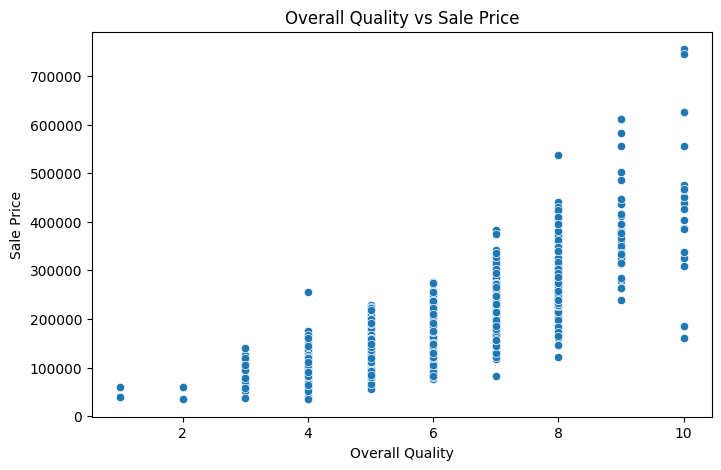

In [65]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

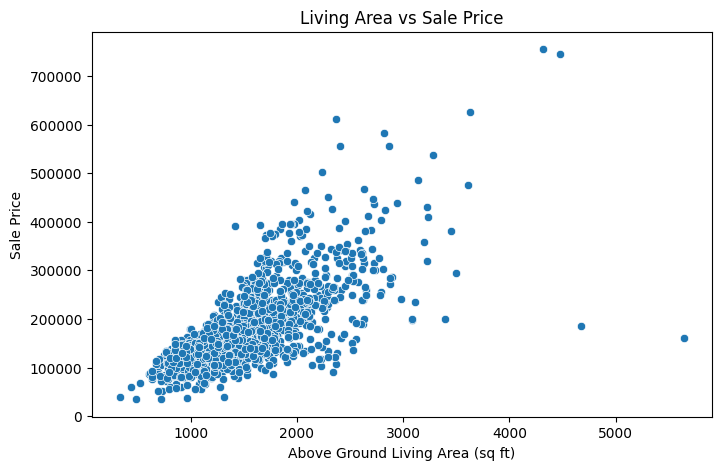

In [66]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

In [67]:
df.nlargest(10, "GrLivArea")[
    ["GrLivArea", "OverallQual", "SalePrice"]
]

,GrLivArea,OverallQual,SalePrice
1298,5642,10,160000
523,4676,10,184750
1182,4476,10,745000
691,4316,10,755000
1169,3627,10,625000
185,3608,10,475000
304,3493,7,295000
1268,3447,8,381000
635,3395,6,200000
769,3279,8,538000


In [68]:
df.loc[[1298, 523]].T

,1298,523
Id,1299,524
MSSubClass,60,60
MSZoning,RL,RL
LotFrontage,313.0,130.0
LotArea,63887,40094
...,...,...
MoSold,1,10
YrSold,2008,2007
SaleType,New,New
SaleCondition,Partial,Partial


In [70]:
df_clean = df.drop(index=[1298, 523])

In [71]:
print("Original rows:", len(df))
print("After removing outliers:", len(df_clean))

Original rows: 1460
After removing outliers: 1458


In [73]:
X_clean = df_clean.drop("SalePrice", axis=1)
y_clean = np.log1p(df_clean["SalePrice"])

In [74]:
X_clean = pd.get_dummies(X_clean, drop_first=True)

In [75]:
print("X shape:", X_clean.shape)
print("y shape:", y_clean.shape)

print("Missing values:", X_clean.isnull().sum().sum())
print("Object columns:", len(X_clean.select_dtypes(include=["object"]).columns))

X shape: (1458, 259)
y shape: (1458,)
Missing values: 0
Object columns: 0


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

In [77]:
model_clean = LinearRegression()

In [78]:
model_clean.fit(X_train, y_train)

LinearRegression()

In [79]:
y_pred_log = model_clean.predict(X_test)

In [80]:
y_pred_clean = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

In [81]:
print("MAE :", mean_absolute_error(y_test_actual, y_pred_clean))
print("MSE :", mean_squared_error(y_test_actual, y_pred_clean))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_clean)))
print("R²  :", r2_score(y_test_actual, y_pred_clean))

MAE : 15509.42580279525
MSE : 478873158.40707076
RMSE: 21883.17066622364
R²  : 0.913306155909778


In [82]:
top_features = correlation.abs().sort_values(
    ascending=False
).head(15)

print(top_features)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [83]:
top_features = correlation.drop("SalePrice").abs().sort_values(
    ascending=False
).head(10)

print(top_features)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [84]:
selected_features = top_features.index.tolist()

X_selected = df_clean[selected_features]
y_selected = np.log1p(df_clean["SalePrice"])

In [85]:
print(X_selected.shape)

(1458, 10)


In [86]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y_selected,
    test_size=0.2,
    random_state=42
)

In [87]:
model_selected = LinearRegression()

model_selected.fit(
    X_train_sel,
    y_train_sel
)

LinearRegression()

In [88]:
y_pred_sel_log = model_selected.predict(X_test_sel)

y_pred_sel = np.expm1(y_pred_sel_log)
y_test_sel_actual = np.expm1(y_test_sel)

In [89]:
print("MAE :", mean_absolute_error(y_test_sel_actual, y_pred_sel))
print("MSE :", mean_squared_error(y_test_sel_actual, y_pred_sel))
print("RMSE:", np.sqrt(mean_squared_error(y_test_sel_actual, y_pred_sel)))
print("R²  :", r2_score(y_test_sel_actual, y_pred_sel))

MAE : 19486.535221223498
MSE : 725232267.8586076
RMSE: 26930.136796136176
R²  : 0.8687059985402518


In [90]:
from sklearn.preprocessing import StandardScaler

In [91]:
scaler = StandardScaler()

In [92]:
X_train_scaled = scaler.fit_transform(X_train)

In [93]:
model_scaled = LinearRegression()

model_scaled.fit(X_train_scaled, y_train)

LinearRegression()

In [95]:
X_test_scaled = scaler.transform(X_test)

In [96]:
y_pred_scaled_log = model_scaled.predict(X_test_scaled)

y_pred_scaled = np.expm1(y_pred_scaled_log)
y_test_scaled_actual = np.expm1(y_test)

In [97]:
print("MAE :", mean_absolute_error(y_test_scaled_actual, y_pred_scaled))
print("MSE :", mean_squared_error(y_test_scaled_actual, y_pred_scaled))
print("RMSE:", np.sqrt(mean_squared_error(y_test_scaled_actual, y_pred_scaled)))
print("R²  :", r2_score(y_test_scaled_actual, y_pred_scaled))

MAE : 15509.42580279788
MSE : 478873158.4071174
RMSE: 21883.170666224705
R²  : 0.9133061559097696


In [98]:
results = pd.DataFrame({
    "Model": [
        "Original Linear Regression",
        "Log Target",
        "Log + Outliers Removed",
        "Log + Outliers + Top 10 Features",
        "Log + Outliers + Scaling"
    ],

    "MAE": [
        23922.63,
        15522.17,
        15509.43,
        19486.54,
        15509.43
    ],

    "RMSE": [
        83010.70,
        25455.23,
        21883.17,
        26930.14,
        21883.17
    ],

    "R2": [
        0.1016,
        0.9155,
        0.9133,
        0.8687,
        0.9133
    ]
})

results

,Model,MAE,RMSE,R2
0,Original Linear Regression,23922.63,83010.70,0.1016
1,Log Target,15522.17,25455.23,0.9155
2,Log + Outliers Removed,15509.43,21883.17,0.9133
3,Log + Outliers + Top 10 Features,19486.54,26930.14,0.8687
4,Log + Outliers + Scaling,15509.43,21883.17,0.9133


In [99]:
new_house = df_clean.drop("SalePrice", axis=1).iloc[[0]]

new_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,0,None,None,None,0,2,2008,WD,Normal


In [101]:
new_house_encoded = pd.get_dummies(
    new_house,
    drop_first=True
)

In [102]:
new_house_encoded = new_house_encoded.reindex(
    columns=X_clean.columns,
    fill_value=0
)

In [103]:
print(new_house_encoded.shape)

(1, 259)


In [104]:
prediction_log = model_clean.predict(new_house_encoded)

prediction = np.expm1(prediction_log)

print("Predicted House Price:", prediction[0])

Predicted House Price: 23314.22804187535


In [105]:
actual_price = df_clean["SalePrice"].iloc[0]

print("Actual Price:", actual_price)
print("Predicted Price:", prediction[0])
print("Difference:", actual_price - prediction[0])

Actual Price: 208500
Predicted Price: 23314.22804187535
Difference: 185185.77195812465


In [106]:
new_house_test = X_test.iloc[[0]]

In [107]:
prediction_log = model_clean.predict(new_house_test)

prediction = np.expm1(prediction_log)[0]

In [108]:
actual_price = np.expm1(y_test.iloc[0])

In [109]:
print("Actual Price:", actual_price)
print("Predicted Price:", prediction)
print("Difference:", actual_price - prediction)

Actual Price: 189999.9999999999
Predicted Price: 224264.22946397425
Difference: -34264.229463974334


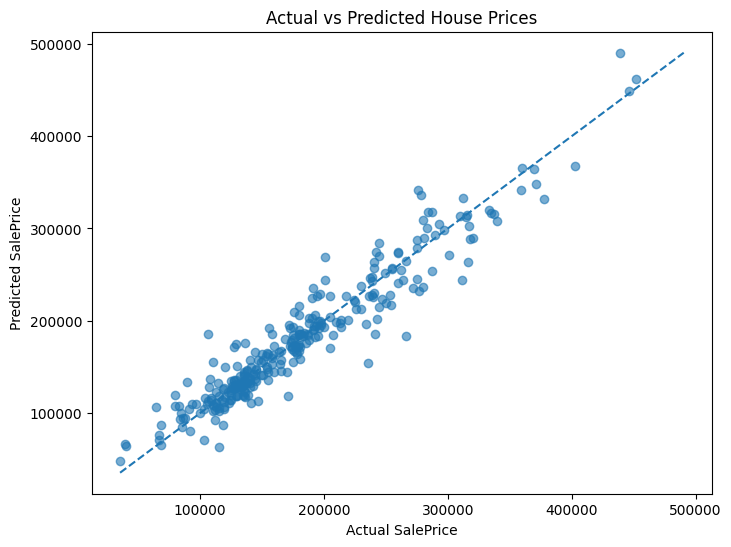

In [110]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_actual, y_pred_clean, alpha=0.6)

# Perfect prediction line
min_price = min(y_test_actual.min(), y_pred_clean.min())
max_price = max(y_test_actual.max(), y_pred_clean.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")

plt.show()

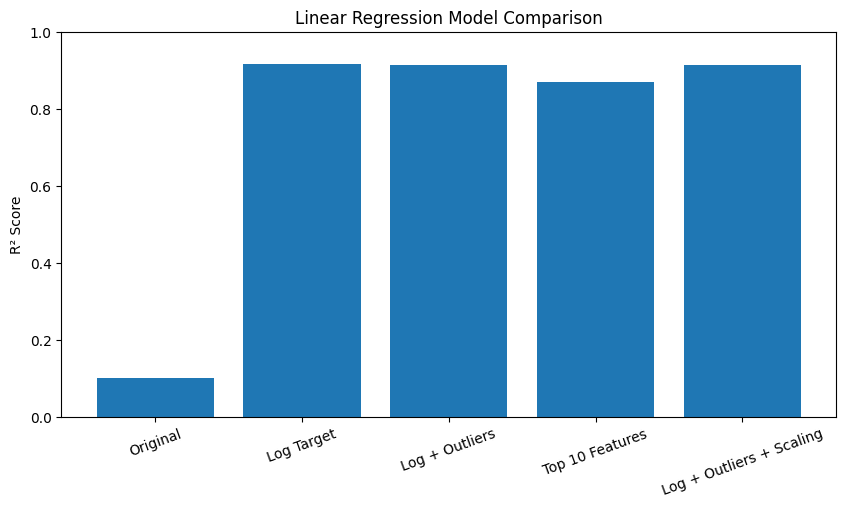

In [111]:
models = [
    "Original",
    "Log Target",
    "Log + Outliers",
    "Top 10 Features",
    "Log + Outliers + Scaling"
]

r2_scores = [
    0.1016,
    0.9155,
    0.9133,
    0.8687,
    0.9133
]

plt.figure(figsize=(10,5))

plt.bar(models, r2_scores)

plt.ylabel("R² Score")
plt.title("Linear Regression Model Comparison")

plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

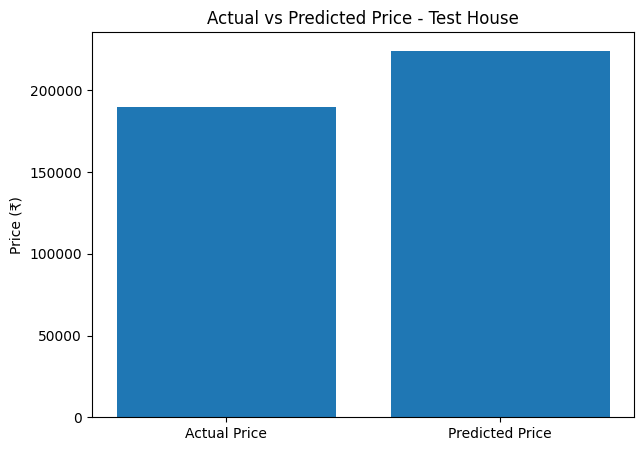

In [112]:
labels = ["Actual Price", "Predicted Price"]
values = [actual_price, prediction]

plt.figure(figsize=(7,5))

plt.bar(labels, values)

plt.ylabel("Price (₹)")
plt.title("Actual vs Predicted Price - Test House")

plt.show()